In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

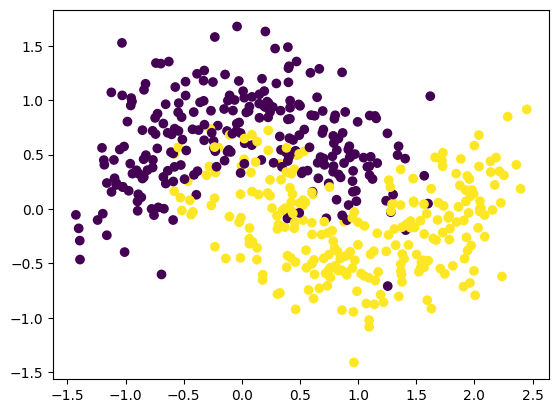

In [ ]:
x, y = make_moons(n_samples=500, noise=0.3, random_state=0)
# on génère un jeu de données en forme de croissant (moons) avec 500 échantillons,
# un bruit de 0.3 et une graine aléatoire de 0 pour assurer la reproductibilité des résultats
plt.scatter(x[:,0], x[:, 1], c=y)

In [3]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 5)

In [4]:
# Volting  classifier

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Volting  classifier

# le volting classifier est une technique d'ensemble qui combine les prédictions de plusieurs modèles de classification pour améliorer les performances globales du modèle.
# dans ce cas, nous allons utiliser trois modèles de classification différents :
# - SGDClassifier : un classificateur linéaire qui utilise la descente de gradient stochastique pour optimiser les poids du modèle
# - DecisionTreeClassifier : un classificateur basé sur des arbres de décision qui divise les données en fonction de caractéristiques pour faire des préd
from sklearn.ensemble import VotingClassifier


In [ ]:
model_1 = SGDClassifier(random_state=0)
model_2 = DecisionTreeClassifier(random_state=0)
model_3 = KNeighborsClassifier(n_neighbors=2)
model_4 = VotingClassifier([('SGD', model_1),
                            ('Tree',model_2),
                            ('KNN', model_3)], voting='hard')    #Pas efficaces

for model in (model_1, model_2, model_3, model_4):
    model.fit(x_train, y_train)
    print(model.__class__.__name__, model.score(x_test, y_test))

SGDClassifier 0.86
DecisionTreeClassifier 0.88
KNeighborsClassifier 0.89
VotingClassifier 0.88


In [14]:
#  Baggin
# le bagging est une technique d'ensemble qui consiste à entraîner 
# plusieurs modèles de classification sur des sous-échantillons aléatoires 
# du jeu de données d'entraînement, puis à combiner leurs prédictions pour
#  obtenir une prédiction finale plus robuste et plus précise.


from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

In [15]:
'''model = BaggingClassifier(base_estimator=KNeighborsClassifier(),n_estimators=100)

model.fit(x_train, y_train)
model.score(x_test, y_test)'''

'model = BaggingClassifier(base_estimator=KNeighborsClassifier(),n_estimators=100)\n\nmodel.fit(x_train, y_train)\nmodel.score(x_test, y_test)'

In [ ]:
model = RandomForestClassifier(n_estimators=100)
# le RandomForestClassifier est une variante du bagging qui utilise des arbres
#  de décision comme modèles de base, et qui introduit une randomisation 
# supplémentaire en sélectionnant aléatoirement un sous-ensemble de caractéristiques à chaque division de l'arbre, ce qui permet d'améliorer la diversité des modèles et les performances globales du modèle d'ensemble.

model.fit(x_train, y_train)
model.score(x_test, y_test)

0.88

In [ ]:
# Boosting 
# le boosting est une technique d'ensemble qui consiste à entraîner
#  plusieurs modèles de classification de manière séquentielle, en mettant 
# l'accent sur les échantillons mal classés par les modèles précédents, afin 
# d'améliorer les performances globales du modèle d'ensemble.


from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [11]:
model = AdaBoostClassifier(n_estimators=100)
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.89

In [ ]:
#Stacking 
# le stacking est une technique d'ensemble qui combine les prédictions
#  de plusieurs modèles de classification de base en utilisant un modèle 
# de méta-apprentissage pour faire la prédiction finale, ce qui permet 
# d'améliorer les performances globales du modèle d'ensemble en exploitant 
# les forces de chaque modèle de base.

from sklearn.ensemble import StackingClassifier

In [13]:

model_4 = StackingClassifier([('SGD', model_1),
                            ('Tree',model_2),
                            ('KNN', model_3)], final_estimator=KNeighborsClassifier())

model.fit(x_train, y_train)
model.score(x_test, y_test)

0.89